<a href="https://colab.research.google.com/github/harsha-9977/AIML/blob/main/Exp6_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

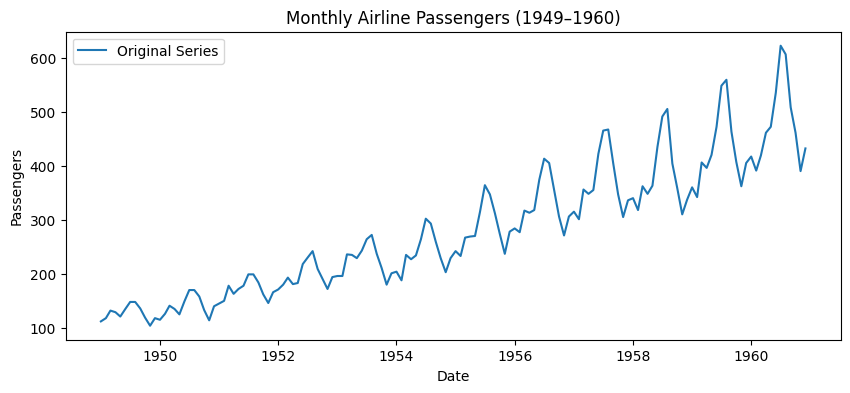

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


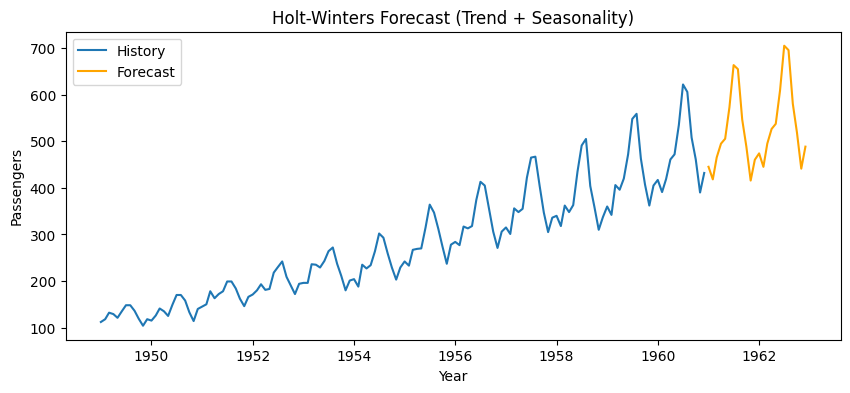

In [1]:
# =====================================================
# 1️⃣ Holt-Winters: Triple Exponential Smoothing
# =====================================================

# Step 1: Read Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Use a real dataset: monthly airline passengers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url, parse_dates=['Month'])
data.set_index('Month', inplace=True)

# Step 2: Explore
plt.figure(figsize=(10,4))
plt.plot(data['Passengers'], label='Original Series')
plt.title("Monthly Airline Passengers (1949–1960)")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

# Step 3: Model
model = ExponentialSmoothing(
    data['Passengers'],
    trend='add',
    seasonal='mul',   # multiplicative handles increasing seasonal amplitude
    seasonal_periods=12
)

# Step 4: Fit & Forecast
fit = model.fit(optimized=True)
forecast = fit.forecast(24)

# Step 5: Plot
plt.figure(figsize=(10,4))
plt.plot(data['Passengers'], label="History")
plt.plot(forecast, label="Forecast", color='orange')
plt.title("Holt-Winters Forecast (Trend + Seasonality)")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 - 6s - 959ms/step - loss: 0.2585 - mae: 0.2585 - val_loss: 0.2839 - val_mae: 0.2839
Epoch 2/50
6/6 - 0s - 59ms/step - loss: 0.0940 - mae: 0.0940 - val_loss: 0.1147 - val_mae: 0.1147
Epoch 3/50
6/6 - 0s - 61ms/step - loss: 0.0791 - mae: 0.0791 - val_loss: 0.1981 - val_mae: 0.1981
Epoch 4/50
6/6 - 0s - 58ms/step - loss: 0.0742 - mae: 0.0742 - val_loss: 0.1328 - val_mae: 0.1328
Epoch 5/50
6/6 - 0s - 35ms/step - loss: 0.0708 - mae: 0.0708 - val_loss: 0.1296 - val_mae: 0.1296
Epoch 6/50
6/6 - 0s - 34ms/step - loss: 0.0698 - mae: 0.0698 - val_loss: 0.1500 - val_mae: 0.1500
Epoch 7/50
6/6 - 0s - 39ms/step - loss: 0.0690 - mae: 0.0690 - val_loss: 0.1403 - val_mae: 0.1403


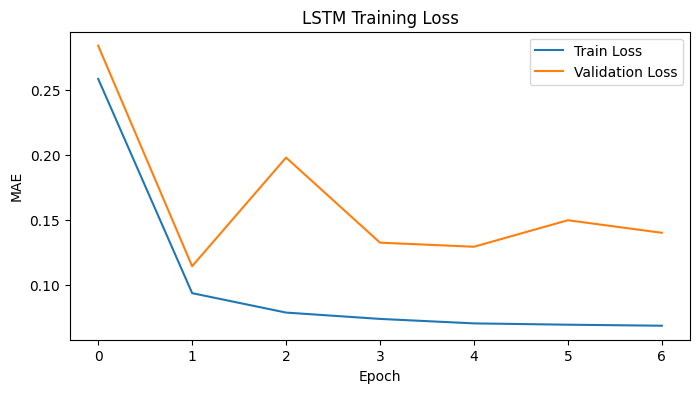

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step


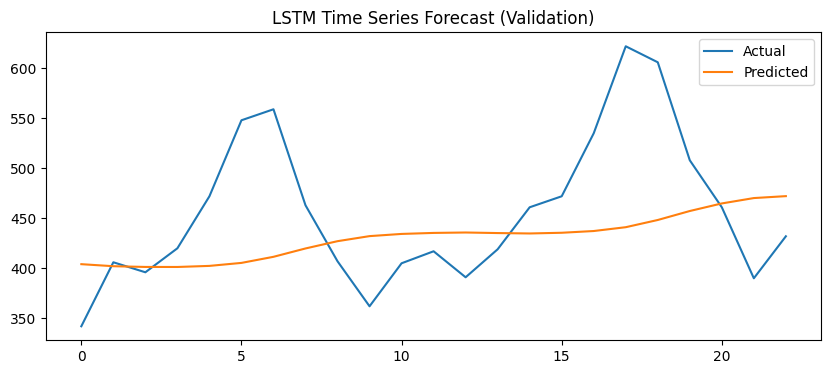

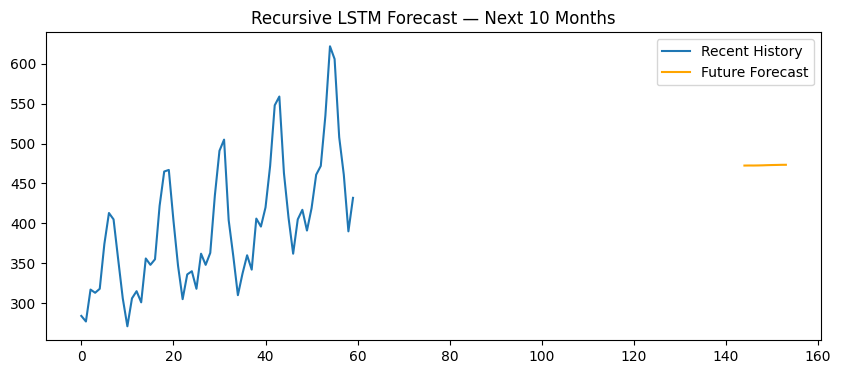

In [3]:
# =====================================================
# 2️⃣ LSTM for Time-Series Forecast
# =====================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

# Step 1: Pre-process
# We'll use the same airline data
values = data['Passengers'].values.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled = scaler.fit_transform(values)

def make_windows(data, window=30):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = make_windows(scaled, 30)
split = int(len(X)*0.8)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]
X_train = X_train.reshape(-1,30,1)
X_val = X_val.reshape(-1,30,1)

# Step 2: Define Model
model = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(30,1)),
    layers.LSTM(32),
    layers.Dense(1)
])

# Step 3: Train
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=2
)

# Plot training loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.show()

# Step 4: Predict
pred = model.predict(X_val)
pred_inv = scaler.inverse_transform(pred)
y_true_inv = scaler.inverse_transform(y_val)

plt.figure(figsize=(10,4))
plt.plot(y_true_inv, label='Actual')
plt.plot(pred_inv, label='Predicted')
plt.title("LSTM Time Series Forecast (Validation)")
plt.legend()
plt.show()

# Step 5: Future Forecast
# Recursive prediction: last 30 points → predict next 10
# ✅ Fixed recursive forecast loop
last_window = scaled[-30:].flatten().tolist()   # ensure it's a flat list
future_preds = []

for _ in range(10):
    x = np.array(last_window[-30:]).reshape(1,30,1)
    next_pred = model.predict(x, verbose=0)[0,0]  # extract scalar directly
    future_preds.append(next_pred)
    last_window.append(float(next_pred))  # append scalar, not array

# Inverse scale to get actual forecast
future = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))

plt.figure(figsize=(10,4))
plt.plot(data['Passengers'].values[-60:], label="Recent History")
plt.plot(np.arange(len(data), len(data)+10), future, label="Future Forecast", color='orange')
plt.title("Recursive LSTM Forecast — Next 10 Months")
plt.legend()
plt.show()
